In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

Load the autoencoder model from the models folder.


In [2]:
with open("models/autoencoder.pt", "rb") as f:
    autoencoder = torch.load(f, weights_only=False).to("cpu")
autoencoder.eval()

Autoencoder(
  (encoder): Encoder(
    (encoder): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Flatten(start_dim=1, end_dim=-1)
      (5): Linear(in_features=165888, out_features=200, bias=True)
      (6): ReLU()
    )
  )
  (decoder): Decoder(
    (decoder): Sequential(
      (0): Linear(in_features=200, out_features=165888, bias=True)
      (1): ReLU()
      (2): Unflatten(dim=1, unflattened_size=(32, 54, 96))
      (3): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (4): ReLU()
      (5): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
      (6): Sigmoid()
    )
  )
)

Load an example image from the images folder.


In [3]:
image_path = "notebooks/images/20230728-083036-IPC608_8B64_165.jpg"
image = Image.open(image_path).convert("RGB")
image = image.resize((384, 216))

Convert image to tensor and normalize it.


In [4]:
image_tensor = torch.tensor(np.array(image)).permute(2, 0, 1).unsqueeze(0).float() / 255.0

Pass the image through the autoencoder


In [5]:
with torch.no_grad():
    encoded_image = autoencoder.encoder(image_tensor)
    decoded_image = autoencoder.decoder(encoded_image)

Convert the decoded image back to a PIL image


In [6]:
decoded_image = decoded_image.squeeze().permute(1, 2, 0).numpy()
decoded_image = (decoded_image * 255).astype(np.uint8)
decoded_image = Image.fromarray(decoded_image)

Plot the original and decoded images


Encoded image: 
tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  5.5254,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.

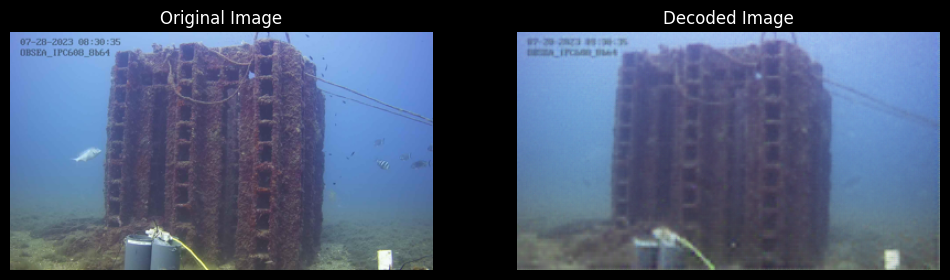

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(decoded_image)
axes[1].set_title("Decoded Image")
axes[1].axis("off")

print(f"Encoded image: \n{encoded_image}")